<h1 style="font-size:5em; font-family:fantasy; color:#00204a; font-weight:700;">Hotel Booking Project</h1>

<h1 style="font-size:3em;  font-family:roboto, sans-serif; color:#005792; font-weight:700">Objective</h1>
<ul style="font-size:1em; font-weight:400; color:#00bbf0">
    <li>Import Libraries</li>
    <li>Import Dataset</li>
    <li>Understanding Dataset</li>
    <li>Data Preperation</li>
    <li>Feature transformation</li>
    <li>New Feature Development</li>
    <li>Exporting Clean Dataset</li>
</ul>

<h2 style="color:#fdb44b; font-size:2em">Libraries</h2>

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
from datetime import date
from sklearn.preprocessing import LabelEncoder
from jinja2 import Template
import webbrowser


<h2 style="font-size:2em; color:#fdb44b;">Data Understanding and Preperation Pipeline</h2> 

In [5]:
class pre_data_clean_func:
    # data information
    def data_info(data_url):
        df = pd.read_csv(data_url)
        return df.info() 
    # required pattern's from dataset we have total count , average , standard of deviation value , min value , max value, q1 , q2 and q3
    def data_describe(data_url):
        df = pd.read_csv(data_url)
        return df.describe()
    # all null value's
    def data_null_colums(data_url):
        df = pd.read_csv(data_url)
        return df.isna().sum()
    # duplicate row
    def duplicate_data(data_url):
        df= pd.read_csv(data_url)
        query = df[df.duplicated()]
        count = df.duplicated().sum()
        return query, count
    def report(data_url):
        template = Template("""<h1>Pre-EDA-Report</h1>
        <p>Duplicate Data Count: {{ duplicated_count }}</p>
        <p>  Null Columns : {{ null_col }}</p>
        <p>  Null Data Count: {{null_count}} </p>
        <h3> Pre-Cleaning-Insight</h3>
        <p> Customer Cancel Rate: {{cancel_rate}}
        <p> Max Lead Time: {{lead_time}} </p>
        <p> Max Average Daily Rate: {{adr_max}}</p>
        <p> Customer With No Deposit: {{no_deposit_per}}</p>
        <p> Repeated Customer Rate: {{repeated_cust_per}}"""
        )
        # feching data 
        df = pd.read_csv(data_url)
        # variable's
        
        duplicated_count= df.duplicated().sum()
        null_col_count = df.isna().sum()
        null_count = sum(null_col_count.values)
        null_col= [i for i,j in zip(null_col_count.keys(), null_col_count.values) if j > 0]
        q =df["is_canceled"].value_counts()[1]
        total_record = len(df)
        cancel_rate =np.round(q/total_record *100) # probality for cancelation
        # Maximum Lead time
        lead_time= max(df['lead_time'])
        adr_max = max(df["adr"])
        # no deposit percentage 
        no_deposit =df["deposit_type"].value_counts()["No Deposit"]
        no_deposit_per = np.round(no_deposit/total_record*100) # probality for no deposit

        # repeated customer probality 
        repeated_cust =df['is_repeated_guest'].value_counts()[1]
        repeated_cust_per = np.round(repeated_cust/total_record*100)
        
        html_report = template.render(duplicated_count = duplicated_count, null_col= null_col, 
                                      null_count=null_count, cancel_rate=cancel_rate, lead_time= lead_time, adr_max=adr_max,
                                      repeated_cust_per=repeated_cust_per, no_deposit_per= no_deposit_per)
        with open("report.html", "w") as f:
            f.write(html_report)
        webbrowser.open("report.html")

<h3 style="color:#edb1f1">Cleaning Dataset Function</h3>

In [7]:
def cleaning_dataset(data_url):
    # fetching dataset
    df = pd.read_csv(data_url)
    # dropping duplicated row's
    df.drop_duplicates(inplace=True)
    # Filling null values
    # Replace missing values safely
    df["agent"]   = df["agent"].fillna(0)
    df["company"] = df["company"].fillna(0)
    df["children"] = df["children"].fillna(df["children"].mean())
    df["country"]  = df["country"].fillna(df["country"].mode()[0])
    return df

<h3 style="color:#edb1f1">Outlier Detention and Removal for ADR</h3>

In [17]:
def outlier_removal(outlier_col,df):
    # Detecting Outlier
    sns.boxplot(df[outlier_col])
    plt.xlabel(outlier_col)
    plt.show()
    # outlier removal 
    # quantile 1 and quantile 3
    Q1=df[outlier_col].quantile(0.25)
    Q3=df[outlier_col].quantile(0.75)
    # IQR value
    IQR = Q3-Q1
    # lower and upper fench
    Lower= Q1 - 1.5 * IQR
    Upper= Q3 + 1.5 * IQR
    # filtering outlier 
    df = df[(df[outlier_col]>=Lower) & (df[outlier_col]<=Upper)]

    # visualizing outlier remvoed dataset
    sns.boxplot(df[outlier_col])
    plt.xlabel(outlier_col)
    plt.show()
    return df
    

<h2 style="font-size:2em;color:#fdb44b;">Feature Engineering</h2>

<h3 style="color:#edb1f1">Fixing Categorical Variable and Feature Transformation</h3>

In [44]:
def fix_date_col(df, date_col):# label encoder + date fixing function
    # date fix
    day =[]
    month =[]
    year= []
    rev_date = pd.to_datetime(df[date_col])
    for i in  rev_date:
        day.append(i.day)
        month.append(i.month)
        year.append(i.year)
    # putting back value 
    df["reservation_status_day"]= day
    df["reservation_status_month"]=month
    df["reservation_status_year"]=year

    # removing date_col
    df.drop(date_col,axis=1,inplace=True)
    
    return df

In [32]:
def fix_categorical_col(df):
    encoder ={}
    df_copy = df.copy() # copying dataset
    for i in df_copy.columns:
        if df_copy[i].dtype == object:
            label = LabelEncoder()
            df_copy[i]=label.fit_transform(df_copy[i])
            encoder[i]=label
    return df_copy, encoder

<h3 style="color:#edb1f1;">Feature Development</h3>

In [38]:
def add_feature(df_copy):
    df_copy["guest_total_stay"]= df_copy["stays_in_weekend_nights"]+df_copy["stays_in_week_nights"]
    # Long stay guest 
    df_copy["is_stay_long"]=[ 1 if i > 7  else 0 for i in df_copy["guest_total_stay"] ]
    # total revenue per booking 
    df_copy["total_revenue"] = df_copy["adr"] * df_copy["guest_total_stay"] 
    return df_copy


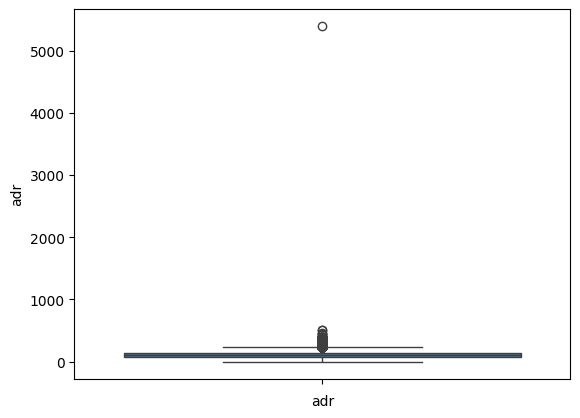

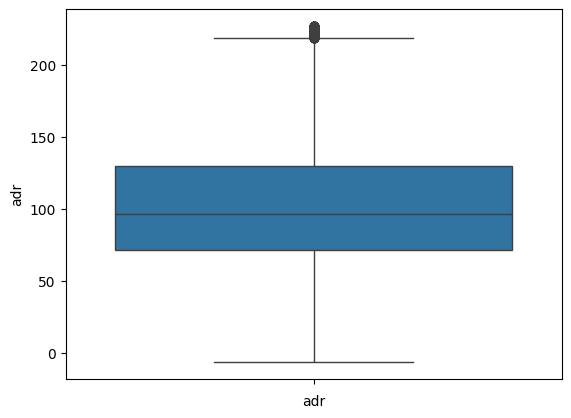

In [50]:
# function workflow
df =cleaning_dataset("hotel_bookings.csv")
df = outlier_removal('adr',df)
df = fix_date_col(df,"reservation_status_date")
df = add_feature(df)
df_copy = df.copy()
df_copy, encoder =df_copy

<h3 style="color:#edb1f1;">Exporting Dataset</h3>

In [ ]:
df_copy.to_csv(r"c:/users/gautam/downloads/hotel_booking_clean_1.csv",index=False)
df.to_csv(r"c:/users/gautam/downloads/hotel_booking_clean_2.csv",index=False)